# TODO give this a better writeup
Currently copied from nn.ipynb, except a pickle file, Data_example_1D.pickle, from the salt repo (GUI) is used

Data from the example is used instead of the torch generated data.

TODO: there's a double vs float error later in the notebook, figure out typing stuff

# Stochastic Neural Network

Here we fit a stochastic neural network to two correlated outputs drawn from

$$ y_1(x) = \sin(\pi x) + \varepsilon_1 $$

and

$$
y_2(x) = \cos(\pi x) + \varepsilon_2
$$ 

with small Gaussian noise terms. The surrogate is a single-hidden-layer `tanh` network

$$ \hat{\mathbf{y}}(x) = W_2 \sigma(W_1 x + b_1) + b_2 $$

whose final-layer weights obey stochastic priors so we can sample functions.

In [13]:
# Import statements
import matplotlib.pyplot as plt
import torch
import numpy as np
import pickle  # for loading from the pickle file

from pypolymix.parameter_groups import IIDGaussianGroup, DeterministicGroup
from pypolymix.surrogate_models import NeuralNetwork
from pypolymix import StochasticModel

In [14]:
# Set random seed
_ = torch.manual_seed(2048)

After the pickle file is parsed into an object, the object has

- one input: obj['data']['x'], which is a Numpy Array
- one output: obj['data']['U']['u'], which is a Numpy Array

In [19]:
with open("Data_example_2D.pickle", "rb") as f:
    obj = pickle.load(f)
obj

{'data': {'x1': array([-0.33975469, -0.06907272, -0.17979853, ..., 35.05144388,
         34.67361962, 35.09477575], shape=(175000,)),
  'x2': array([ 0.19491692, -0.1022902 ,  0.29936746, ..., 49.58621192,
         49.79646296, 49.78121542], shape=(175000,)),
  'x': array([[-0.33975469,  0.19491692],
         [-0.06907272, -0.1022902 ],
         [-0.17979853,  0.29936746],
         ...,
         [35.05144388, 49.58621192],
         [34.67361962, 49.79646296],
         [35.09477575, 49.78121542]], shape=(175000, 2)),
  'U': {'u': array([  1.19902006,  -0.6639478 ,   1.88374065, ..., 120.45177259,
          119.17548508, 121.95499968], shape=(175000,))}}}

nn.txt generated synthetic data for X, y1, and y2. Here I use the pickle data for X and Y 

In [ ]:
def dict_to_tensors(obj):
    '''
    Input schema
    {
        'data': {
            'var1': np.array([values...]),  # Input variable 1
            'var2': np.array([values...]),  # Input variable 2
            ...
            'U': {
                'output1': np.array([values...]),  # Output variable 1
                'output2': np.array([values...]),  # Output variable 2
                ...
            }
        }
    }

    Note that all input and output keys map to numpy arrays of the same length
    
    Returns 2-D float tensor of input vars, 2-D float tensor of output vars
    '''
    output_dict = obj["data"]["U"]
    # k != x is a workaround
    # since Data_example_2D.pickle has 'x' already pre-built
    input_dict = {k: v for k, v in obj["data"].items() if k != "U" and k != 'x'}

    # conversion to numpy.ndarray done because of a warning that
    # creating a tensor from a list of numpy.ndarrays is extremely slow
    X_np = np.column_stack(list(input_dict.values())).astype(np.float32)
    Y_np = np.column_stack(list(output_dict.values())).astype(np.float32)
    return torch.from_numpy(X_np), torch.from_numpy(Y_np)

In [27]:
X, Y = dict_to_tensors(obj)
X

tensor([[-0.3398,  0.1949],
        [-0.0691, -0.1023],
        [-0.1798,  0.2994],
        ...,
        [35.0514, 49.5862],
        [34.6736, 49.7965],
        [35.0948, 49.7812]])

Two scatter plots (one per output) help visualize the phase shift between $\sin$ and $\cos$ so we know what structure the neural network must reproduce.

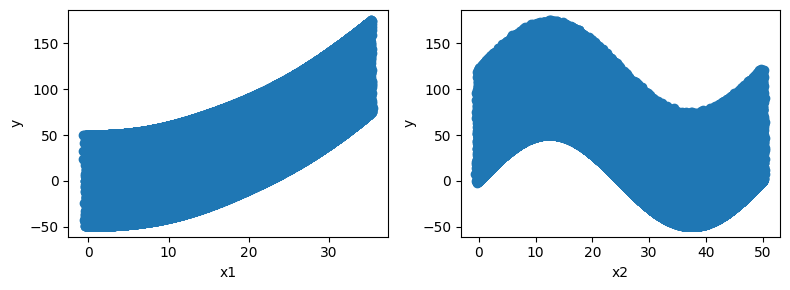

In [ ]:
# Plot data
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (x, ax) in enumerate(zip(X.T, axes.flatten())):
    ax.scatter(x, Y)
    ax.set_xlabel(f"x{j + 1}")
    ax.set_ylabel(f"y")
plt.tight_layout()

We configure a width-16, depth-1 tanh network and print how many trainable parameters it contains so we have a sense of model capacity.

In [1]:
# Create a surrogate model
width = 16
depth = 1
surrogate_model = NeuralNetwork(num_inputs=2, num_outputs=1, width=width, depth=depth, activation=torch.nn.functional.tanh)
num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

NameError: name 'NeuralNetwork' is not defined

All weights/biases up through the hidden layer are treated as deterministic, while the output-layer weights and biases follow i.i.d. Gaussian priors. This split lets us capture uncertainty primarily in the mapping from hidden features to the outputs, similar to a Bayesian neural network in the "Bayesian in the last layer" configuration.

In [36]:
# Create parameter groups
parameter_groups = [  # Input layer
    DeterministicGroup("input_layer_weights", width),
    DeterministicGroup("input_layer_biases", width),
]
for j in range(depth - 1):
    parameter_groups += [  # Hidden layers
        DeterministicGroup(f"layer{j + 1}_weights", width * width),
        DeterministicGroup(f"layer{j + 1}_biases", width),
    ]
parameter_groups += [  # Output layer
    IIDGaussianGroup("output_weights", 2 * width),
    IIDGaussianGroup("output_biases", 2),
]

The `StochasticModel` pairs the deterministic neural network with the grouped parameters so that sampling, log-prior penalties, and inference utilities become available.

In [37]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

ValueError: Total number of parameters in parameter groups (66) does not match number of parameters required in model (65)

We pick learning-rate and weight-decay values, set a small `weight_factor` for the distribution loss, introduce a learnable log-precision `log_tau`, and build the AdamW optimizer plus `OneCycleLR` scheduler.

In [33]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 1e-2  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Learnable global precision
log_tau = torch.nn.Parameter(torch.tensor(0.0))  # τ = exp(log_tau)

# Optimizer: AdamW
optimizer = torch.optim.AdamW(
    list(model.parameters()) + [log_tau], lr=lr, weight_decay=weight_decay
)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

Each epoch samples 100 parameter realizations, evaluates the network, computes the precision-scaled MSE on the predictive mean, adds the distribution regularizer, and performs backpropagation followed by the optimizer/scheduler updates.

In [34]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Evaluate parameters and model
    params = model.sample_parameters(num_samples=100)
    Y_hat = surrogate_model(X, params)

    # Losses
    data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat)) / num_samples
    data_loss *= torch.exp(log_tau)
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backprop + step
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

KeyboardInterrupt: 

After training we switch to eval mode, create evenly spaced test points, and ask the stochastic model for 1000 posterior samples so we can estimate predictive uncertainty.

In [ ]:
# Evaluate the model
model.eval()
with torch.no_grad():
    X_test = torch.linspace(X.min(), X.max(), 200).unsqueeze(1)
    Y_test = model(X_test, num_samples=1000)
Y_test[0]

tensor([[  0.6311,  -3.8516],
        [  3.0970,  -1.5607],
        [  5.3433,   0.5115],
        [  7.4382,   2.4273],
        [  9.4769,   4.2781],
        [ 11.6033,   6.2030],
        [ 14.0152,   8.3931],
        [ 16.9519,  11.0810],
        [ 20.6380,  14.4908],
        [ 25.1856,  18.7518],
        [ 30.5328,  23.8521],
        [ 36.4798,  29.6826],
        [ 42.7365,  36.0642],
        [ 48.9754,  42.7404],
        [ 55.0452,  49.5578],
        [ 61.2278,  56.7694],
        [ 68.1857,  64.9940],
        [ 76.6888,  74.8943],
        [ 87.0594,  86.6185],
        [ 97.8495,  98.4799],
        [106.2211, 107.5061],
        [111.0537, 112.6623],
        [113.3864, 115.1311],
        [114.4630, 116.2533],
        [114.9882, 116.7847],
        [115.2770, 117.0644],
        [115.4603, 117.2337],
        [115.5919, 117.3506],
        [115.6943, 117.4395],
        [115.7780, 117.5113],
        [115.8480, 117.5710],
        [115.9073, 117.6216],
        [115.9577, 117.6647],
        [1

For each output dimension we show the mean prediction and the central 90% credible interval obtained from the samples, plus the observed data for reference.

torch.Size([1000, 200, 2])
tensor([[-6.5643e+00, -4.2085e+00, -2.0443e+00, -5.8931e-02,  1.8476e+00,
          3.8431e+00,  6.1765e+00,  9.0541e+00,  1.2769e+01,  1.7358e+01,
          2.2593e+01,  2.8511e+01,  3.4764e+01,  4.1037e+01,  4.7199e+01,
          5.3708e+01,  6.1122e+01,  7.0098e+01,  8.1010e+01,  9.1906e+01,
          1.0013e+02,  1.0484e+02,  1.0706e+02,  1.0809e+02,  1.0857e+02,
          1.0883e+02,  1.0899e+02,  1.0911e+02,  1.0920e+02,  1.0927e+02,
          1.0933e+02,  1.0938e+02,  1.0943e+02,  1.0946e+02,  1.0950e+02,
          1.0952e+02,  1.0955e+02,  1.0957e+02,  1.0959e+02,  1.0960e+02,
          1.0962e+02,  1.0963e+02,  1.0964e+02,  1.0965e+02,  1.0965e+02,
          1.0966e+02,  1.0967e+02,  1.0967e+02,  1.0968e+02,  1.0968e+02,
          1.0968e+02,  1.0969e+02,  1.0969e+02,  1.0969e+02,  1.0969e+02,
          1.0969e+02,  1.0969e+02,  1.0970e+02,  1.0970e+02,  1.0970e+02,
          1.0970e+02,  1.0970e+02,  1.0970e+02,  1.0970e+02,  1.0970e+02,
          1

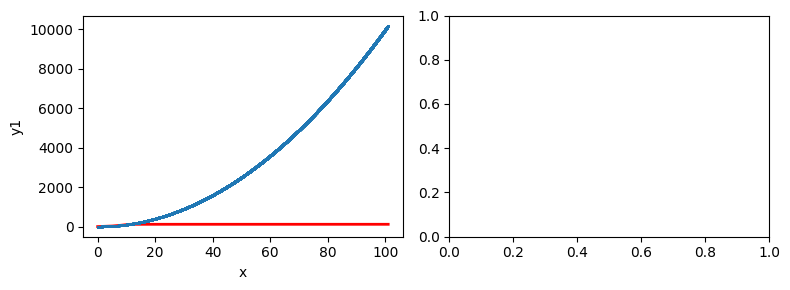

In [ ]:
# Plot prediction
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (y, ax) in enumerate(zip(Y.T, axes.flatten())):
    x = X_test.squeeze(-1)
    q = torch.quantile(Y_test[:, :, j], torch.tensor([0.05, 0.5, 0.95]), axis=0)
    print(Y_test.shape)
    print(q)
    ax.fill_between(x, q[0], q[-1], color="red", alpha=0.5, linewidth=0)
    ax.plot(x, q[1], color="red", linewidth=2)
    ax.scatter(X, y, s=1, zorder=99) # changed dot size
    ax.set_xlabel("x")
    ax.set_ylabel(f"y{j + 1}")
plt.tight_layout()